# 11. Experimentos complementarios

Las preguntas de la reflexión crítica (capítulo 12) piden explicar *por qué* un entorno fue más
rápido, *a partir de qué volumen* PySpark supera a scikit-learn, *qué efecto* tuvo cada condición
obligatoria y *qué diferencias de implementación* explican las discrepancias. Los capítulos 6 y 7
miden una sola configuración; este capítulo varía un factor a la vez:

1. **Volumen de datos**: tiempo de ajuste de tres modelos con fracciones del entrenamiento (1 % a
   100 %) y con el entrenamiento replicado 2 y 4 veces (2,2 y 4,3 millones de filas).
2. **Condiciones obligatorias de Spark**: número de particiones, caché, memoria del driver,
   fracciones de memoria y paralelismo del `CrossValidator`.
3. **Discretización de los árboles** (`maxBins`).
4. **Pérdida *hinge* de `LinearSVC`**.

Estos experimentos son auxiliares: las submuestras y réplicas sirven solo para medir cómo escala
el tiempo; ningún modelo de los capítulos 6 a 10 se entrenó con datos reducidos. Cada
configuración de Spark se ejecuta en un proceso nuevo (`src/exp_spark.py`), porque la memoria y
las demás opciones de la sesión solo se aplican al arrancar la JVM. Los resultados se guardan en
`data/resultados/experimentos.json` y no se recalculan si ya existen.

In [1]:
import json
import os
import subprocess
import sys
import time
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import features as fe
import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 200)
RUTA = u.RESULTADOS / "experimentos.json"
EXP = json.loads(RUTA.read_text()) if RUTA.exists() else {}


def guardar():
    RUTA.write_text(json.dumps(EXP, indent=1, default=float))


def spark_exp(cfg):
    """Ejecuta una configuración en un proceso nuevo (o devuelve el resultado guardado)."""
    clave = "spark|" + json.dumps(cfg, sort_keys=True)
    if clave not in EXP:
        t0 = time.time()
        r = subprocess.run([u.PYTHON_VENV, "../src/exp_spark.py", json.dumps(cfg)], capture_output=True,
                           text=True, env={**os.environ, "PYTHONPATH": os.path.abspath("../src")})
        linea = [l for l in r.stdout.splitlines() if l.startswith("RESULTADO ")]
        if not linea:
            raise RuntimeError(r.stderr[-3000:])
        EXP[clave] = {**json.loads(linea[0][10:]), "t_proceso_s": time.time() - t0}
        guardar()
    return EXP[clave]


def sk_exp(nombre, fn):
    clave = "sklearn|" + nombre
    if clave not in EXP:
        EXP[clave] = fn()
        guardar()
    return EXP[clave]


spark_exp({"tarea": "preparar"})
d = fe.preparar_sklearn()
n = len(d["y_train"])
print(f"Entrenamiento completo: {n:,} filas")

Entrenamiento completo: 1,078,447 filas


## 11.1 ¿A partir de qué volumen supera PySpark a scikit-learn?

Tres modelos con una configuración fija (sin validación cruzada, para aislar el costo de un
ajuste): regresión logística ($\lambda = 10^{-5}$), árbol de profundidad 10 y bosque de 50
árboles de profundidad 10. scikit-learn usa todos los núcleos en el bosque (`n_jobs=-1`); la
regresión logística (`lbfgs`) y el árbol son de un solo hilo en su ciclo principal. PySpark se
mide con los datos repartidos en 40 particiones (como en el capítulo 7) y en 400 (el valor de
`spark.sql.shuffle.partitions` del enunciado), para separar el efecto del volumen del efecto del
particionado. Los tamaños por encima de
1.078.447 se obtienen replicando el entrenamiento completo.

In [2]:
FRACCIONES = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
REPLICAS = [2, 4]
rng = np.random.default_rng(u.SEMILLA)


def datos_tamano(frac, rep):
    if rep > 1:
        return np.vstack([d["X_train"]] * rep), np.concatenate([d["y_train"]] * rep)
    if frac < 1:
        i = rng.choice(n, int(frac * n), replace=False)
        return d["X_train"][i], d["y_train"][i]
    return d["X_train"], d["y_train"]


def sk_modelo(nombre, m):
    if nombre == "lr":
        return LogisticRegression(C=1.0 / (1e-5 * m), solver="lbfgs", max_iter=1000)
    if nombre == "dt":
        return DecisionTreeClassifier(max_depth=10, random_state=u.SEMILLA)
    return RandomForestClassifier(n_estimators=50, max_depth=10, max_features="sqrt", n_jobs=-1,
                                  random_state=u.SEMILLA)


filas = []
for frac, rep in [(f, 1) for f in FRACCIONES] + [(1.0, r) for r in REPLICAS]:
    X = y = None
    for mod in ("lr", "dt", "rf"):
        def medir():
            global X, y
            if X is None:
                X, y = datos_tamano(frac, rep)
            t0 = time.time()
            est = sk_modelo(mod, len(y)).fit(X, y)
            t = time.time() - t0
            s = est.predict_proba(d["X_test"])[:, 1]
            return {"n_train": len(y), "t_ajuste_s": t, "auc_test": roc_auc_score(d["y_test"], s)}
        r = sk_exp(f"escala|{mod}|{frac}|{rep}", medir)
        filas.append({"entorno": "scikit-learn", "modelo": mod, "fraccion": frac, "replicas": rep, **r})
        for part in (40, 400):
            r = spark_exp({"tarea": "escala", "modelo": mod, "fraccion": frac, "replicas": rep,
                           "particiones": part})
            filas.append({"entorno": f"PySpark ({part} part.)", "modelo": mod, "fraccion": frac,
                          "replicas": rep, "n_train": r["n_train"], "t_ajuste_s": r["t_ajuste_s"],
                          "auc_test": r["auc_test"]})
    del X, y
escala = pd.DataFrame(filas)
escala.to_csv(u.RESULTADOS / "exp_escala.csv", index=False)
escala.pivot_table(index=["modelo", "n_train"], columns="entorno", values="t_ajuste_s").round(2)

entorno         PySpark (40 part.)  PySpark (400 part.)  scikit-learn
modelo n_train                                                       
dt     10784                   NaN                  NaN          0.06
       10921                  2.28                 9.29           NaN
       53922                   NaN                  NaN          0.29
       54175                  2.98                12.70           NaN
       107843                 3.76                16.62           NaN
       107844                  NaN                  NaN          0.61
       269321                 4.44                20.72           NaN
       269611                  NaN                  NaN          1.53
       538833                 5.98                21.85           NaN
       539223                  NaN                  NaN          3.23
       1078447                8.08                23.47          6.79
       2156894               11.65                26.20         14.04
       4313788               18.70                33.81         28.58
lr     10784                   NaN                  NaN          0.02
       10921                  3.93                16.53           NaN
       53922                   NaN                  NaN          0.05
       54175                  3.54                13.32           NaN
       107843                 3.65                14.07           NaN
       107844                  NaN                  NaN          0.09
       269321                 4.69                14.76           NaN
       269611                  NaN                  NaN          0.26
       538833                 4.95                13.38           NaN
       539223                  NaN                  NaN          0.48
       1078447                6.01                15.13          1.04
       2156894               10.12                17.78          1.98
       4313788               14.81                24.00          4.09
rf     10784                   NaN                  NaN          0.07
       10921                  7.38                49.53           NaN
       53922                   NaN                  NaN          0.21
       54175                  9.41                54.38           NaN
       107843                11.42                66.37           NaN
       107844                  NaN                  NaN          0.47
       269321                15.26                74.48           NaN
       269611                  NaN                  NaN          1.43
       538833                19.69                81.02           NaN
       539223                  NaN                  NaN          4.15
       1078447               29.91                92.76          9.34
       2156894               49.65               127.65         20.50
       4313788               97.63               175.08         43.02

Las filas con tamaños ligeramente distintos entre entornos (por ejemplo, 10.784 frente a 10.921)
se deben a que cada entorno toma su propia submuestra aleatoria; con el entrenamiento completo y
las réplicas los tamaños son idénticos.

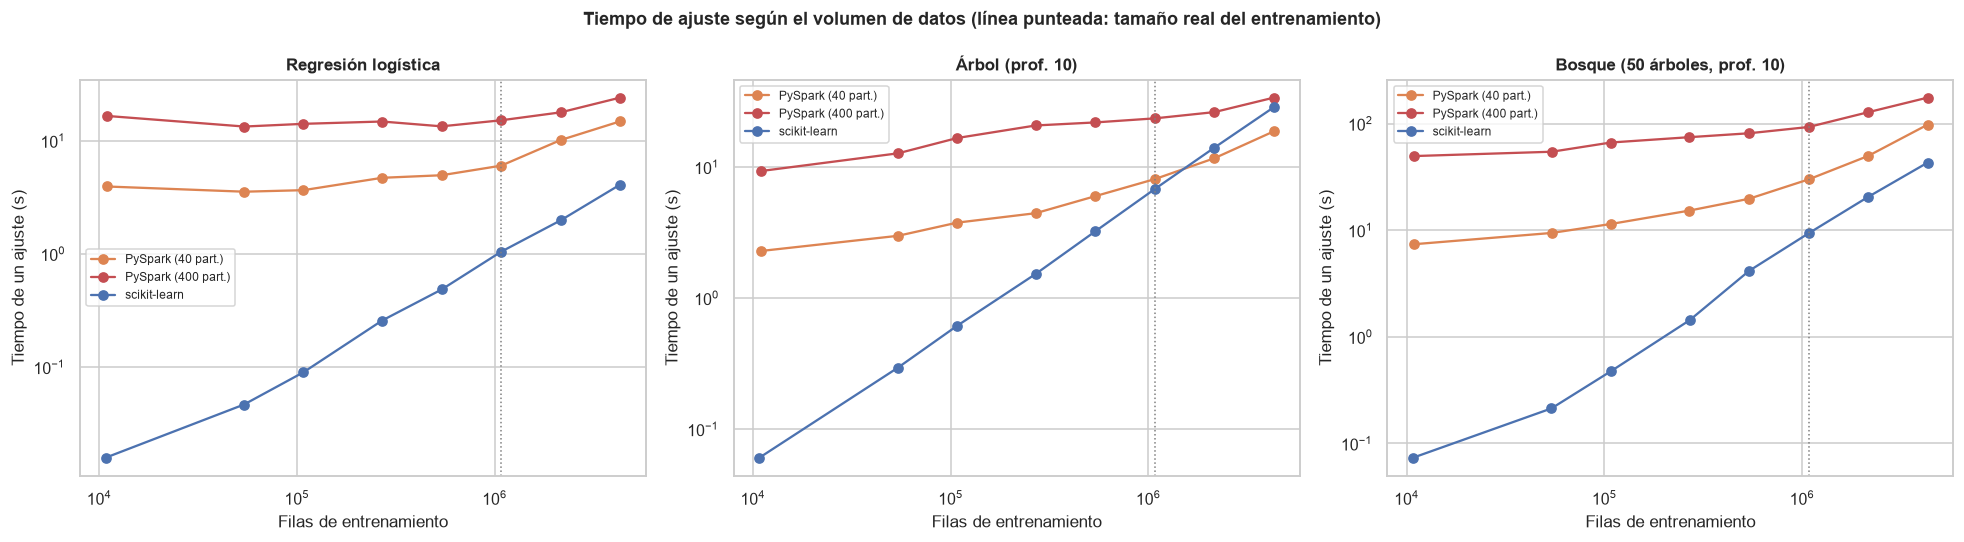

In [3]:
nombres_mod = {"lr": "Regresión logística", "dt": "Árbol (prof. 10)", "rf": "Bosque (50 árboles, prof. 10)"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mod in zip(axes, ("lr", "dt", "rf")):
    for (ent, g), c in zip(escala[escala["modelo"] == mod].groupby("entorno"), ["#DD8452", "#C44E52", "#4C72B0"]):
        g = g.sort_values("n_train")
        ax.plot(g["n_train"], g["t_ajuste_s"], marker="o", label=ent, color=c)
    ax.axvline(n, color="grey", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Filas de entrenamiento")
    ax.set_ylabel("Tiempo de un ajuste (s)")
    ax.set_title(nombres_mod[mod])
    ax.legend(fontsize=8)
fig.suptitle("Tiempo de ajuste según el volumen de datos (línea punteada: tamaño real del entrenamiento)",
             fontsize=12, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "11_escala")
plt.show()

El gráfico en escala log-log muestra dos regímenes. Con pocos datos, el tiempo de PySpark es casi
constante (entre 2 y 7 s con 40 particiones, entre 9 y 54 s con 400): es el costo fijo de
programar trabajos y tareas, que no depende del volumen. scikit-learn, en cambio, crece casi
proporcionalmente al número de filas desde fracciones de segundo. A medida que crecen los datos,
el costo fijo de Spark pesa menos y las curvas se acercan.

In [4]:
cruces = []
for mod in ("lr", "dt", "rf"):
    t = escala[escala["modelo"] == mod].pivot_table(index="n_train", columns="entorno", values="t_ajuste_s")
    for ent in [c for c in t.columns if c.startswith("PySpark")]:
        gana = t.index[t[ent] < t["scikit-learn"]]
        cruces.append({"modelo": nombres_mod[mod], "configuración": ent,
                       "PySpark más rápido desde (filas)": f"{gana.min():,}" if len(gana) else "no ocurre (≤ 4,3 M)",
                       "cociente PySpark/sklearn con 1,08 M": t.loc[n, ent] / t.loc[n, "scikit-learn"]})
pd.DataFrame(cruces).round(2)

,modelo,configuración,PySpark más rápido desde (filas),"cociente PySpark/sklearn con 1,08 M"
0,Regresión logística,PySpark (40 part.),"no ocurre (≤ 4,3 M)",5.76
1,Regresión logística,PySpark (400 part.),"no ocurre (≤ 4,3 M)",14.50
2,Árbol (prof. 10),PySpark (40 part.),"2,156,894",1.19
3,Árbol (prof. 10),PySpark (400 part.),"no ocurre (≤ 4,3 M)",3.46
4,"Bosque (50 árboles, prof. 10)",PySpark (40 part.),"no ocurre (≤ 4,3 M)",3.20
5,"Bosque (50 árboles, prof. 10)",PySpark (400 part.),"no ocurre (≤ 4,3 M)",9.93


**Solo el árbol cruza.** Con 40 particiones, PySpark ajusta el árbol más rápido que scikit-learn
desde unos 2,2 millones de filas (11,7 s frente a 14,0 s) y con 4,3 millones la ventaja es de
1,5 veces (18,7 s frente a 28,6 s). La razón es que `DecisionTreeClassifier` de scikit-learn
usa un solo núcleo, mientras que Spark reparte cada pasada entre los 10; el costo marginal por
millón de filas es de unos 3,3 s en Spark frente a 6,7 s en scikit-learn.

**La regresión logística y el bosque no cruzan** en el rango medido, aunque la brecha se cierra
(de 5,8 a 3,6 veces en la regresión logística y de 3,2 a 2,3 veces en el bosque, entre 1,08 y 4,3
millones de filas). En estos dos casos scikit-learn también usa todo el equipo: `lbfgs` se apoya
en operaciones matriciales vectorizadas y el bosque reparte los árboles entre los 10 núcleos con
`n_jobs=-1`. Su costo marginal por millón de filas (0,9 s y 10,4 s) es menor que el de Spark
(2,7 s y 20,9 s), de modo que en una sola máquina Spark no los alcanzaría con más datos. El
límite de scikit-learn es otro: necesita la matriz completa en memoria (4,3 millones de filas
ocupan 2,5 GB en `float64`), y con unos 100 millones de filas (unos 60 GB) ya no cabría en los
24 GB del equipo. A partir de ese volumen, o con un clúster de varias máquinas, PySpark deja de
ser más lento y pasa a ser la única opción.

Con 400 particiones Spark no supera a scikit-learn en ningún caso y es entre 1,6 y 6,7 veces más
lento que con 40; la penalización es mayor cuanto menos datos hay por partición.

## 11.2 Efecto de las condiciones obligatorias de Spark

Cada fila cambia **un** factor respecto a la configuración del capítulo 7 (sesión obligatoria:
400 particiones de shuffle, 8 GB, `memory.fraction` 0,8 y `storageFraction` 0,3; datos en 40
particiones con caché `MEMORY_AND_DISK`; `CrossValidator` con `parallelism=1`) y mide la
validación cruzada completa de la regresión logística (3 valores de `regParam` × 3 pliegues +
reajuste) y del árbol (3 profundidades × 3 pliegues + reajuste) con el entrenamiento completo.

In [5]:
variantes = {
    "capítulo 7 (datos en 40 particiones)": {},
    "datos en 400 particiones (= shuffle obligatorio)": {"particiones": 400},
    "datos en 10 particiones (1 por núcleo)": {"particiones": 10},
    "memoria del driver 2 GB": {"config": {"spark.driver.memory": "2g", "spark.executor.memory": "2g"}},
    "fracciones de memoria por defecto (0,6 / 0,5)": {"config": {"spark.memory.fraction": "0.6", "spark.memory.storageFraction": "0.5"}},
    "CrossValidator parallelism = 3": {"paralelismo": 3},
}
filas = []
for nombre, extra in variantes.items():
    for tarea in ("lr_cv", "dt_cv"):
        r = spark_exp({"tarea": tarea, **extra})
        filas.append({"variante": nombre, "modelo": "Regresión logística" if tarea == "lr_cv" else "Árbol",
                      "t_cv (s)": r["t_cv_s"], "AUC prueba": r["auc_test"],
                      "caché en memoria (MB)": r.get("cache_memoria_mb"), "caché en disco (MB)": r.get("cache_disco_mb")})
cond = pd.DataFrame(filas)
cond.to_csv(u.RESULTADOS / "exp_condiciones.csv", index=False)
cond.pivot_table(index="variante", columns="modelo", values="t_cv (s)").loc[list(variantes)].round(1)

modelo,Regresión logística,Árbol
variante,,
capítulo 7 (datos en 40 particiones),139.8,70.0
datos en 400 particiones (= shuffle obligatorio),319.2,807.7
datos en 10 particiones (1 por núcleo),122.4,42.9
memoria del driver 2 GB,137.7,78.6
"fracciones de memoria por defecto (0,6 / 0,5)",137.4,69.6
CrossValidator parallelism = 3,135.2,71.3


* **Número de particiones**: es el factor que más pesa. Con los datos en 400 particiones, la
  validación cruzada tarda 2,3 veces más en la regresión logística (319 s frente a 140 s) y 11,5
  veces más en el árbol (808 s frente a 70 s): cada tarea procesa unas 2.700 filas y dedica más
  tiempo a su programación y a combinar los histogramas que a calcular. Con 10 particiones (una
  por núcleo) es todavía algo más rápido (122 s y 43 s).
* **Memoria del driver (2 GB frente a 8 GB) y fracciones de memoria**: efectos pequeños y sin un
  patrón claro (entre −2 s y +9 s). Los datos cacheados ocupan unos 151 MB en memoria y nada en
  disco, muy por debajo de cualquiera de los límites: con este volumen la configuración de memoria
  del enunciado no restringe nada.
* **`CrossValidator(parallelism=3)`**: sin ganancia (135 s y 71 s frente a 140 s y 70 s), porque
  cada ajuste ya ocupa los 10 núcleos.

El AUC de prueba es el mismo en todas las variantes (0,7171 en la regresión logística y entre
0,7009 y 0,7015 en el árbol): la configuración cambia el tiempo, no el modelo.

In [6]:
cond.round(4)

,variante,modelo,t_cv (s),AUC prueba,caché en memoria (MB),caché en disco (MB)
0,capítulo 7 (datos en 40 particiones),Regresión logística,139.8354,0.7171,150.7736,0.0
1,capítulo 7 (datos en 40 particiones),Árbol,69.9965,0.7015,150.7736,0.0
2,datos en 400 particiones (= shuffle obligatorio),Regresión logística,319.2310,0.7171,151.8941,0.0
3,datos en 400 particiones (= shuffle obligatorio),Árbol,807.7333,0.7015,151.8941,0.0
4,datos en 10 particiones (1 por núcleo),Regresión logística,122.4397,0.7171,150.8134,0.0
5,datos en 10 particiones (1 por núcleo),Árbol,42.9478,0.7009,150.8134,0.0
6,memoria del driver 2 GB,Regresión logística,137.7460,0.7171,150.7736,0.0
7,memoria del driver 2 GB,Árbol,78.6145,0.7015,150.7736,0.0
8,"fracciones de memoria por defecto (0,6 / 0,5)",Regresión logística,137.3726,0.7171,150.7736,0.0
9,"fracciones de memoria por defecto (0,6 / 0,5)",Árbol,69.5851,0.7015,150.7736,0.0


### Caché

Sin `persist`, cada pasada de un algoritmo iterativo vuelve a ejecutar todo el linaje: leer y
descomprimir el CSV de 1,6 GB en una sola partición, construir las variables, unir con la
partición y aplicar el `Pipeline`. Una validación cruzada completa sin caché tomaría horas, así que
se compara un ajuste de la regresión logística con exactamente 10 iteraciones de L-BFGS, con y sin
caché, partiendo en ambos casos del CSV original.

In [7]:
cache = pd.DataFrame([
    {"caché": c, **{k: v for k, v in spark_exp({"tarea": "lr_fit", "max_iter": 10, "iter_fijas": True,
                                                  "desde_csv": True, "cache": c}).items()
                    if k in ("t_preparacion_s", "t_ajuste_s", "auc_test")}}
    for c in (True, False)]).set_index("caché")
cache["t_por_iteración (s)"] = cache["t_ajuste_s"] / 10
cache.round(2)

,t_preparacion_s,t_ajuste_s,auc_test,t_por_iteración (s)
caché,,,,
True,35.70,5.16,0.72,0.52
False,100.61,48.98,0.72,4.90


Sin caché, cada iteración de L-BFGS cuesta 4,9 s frente a 0,52 s con caché (9,4 veces más),
porque vuelve a leer y descomprimir el CSV y a reconstruir las variables. La regresión logística
del capítulo 7 hizo 39 iteraciones en el reajuste final y, con 10 ajustes de un número parecido
de iteraciones, del orden de 400 en total; sin caché, solo las iteraciones habrían sumado más de
media hora, frente a menos de 4 minutos. La preparación también se encarece (101 s frente a 36 s) porque sin caché la base
intermedia se recalcula en cada paso del `Pipeline`.

## 11.3 Discretización de los árboles (`maxBins`)

Spark evalúa como candidatos de corte a lo sumo `maxBins − 1` umbrales por variable continua,
elegidos con cuantiles de una muestra; scikit-learn evalúa todos los valores distintos. Se ajusta
árboles de profundidad 5, 10 y 15 con `maxBins` ∈ {32, 128, 512} y se comparan con el árbol
exacto de scikit-learn de la misma profundidad. La profundidad 5 se incluye porque en la
validación cruzada del capítulo 7 es donde más difieren los dos entornos (AUC 0,651 en Spark
frente a 0,695 en scikit-learn).

In [8]:
filas = []
for prof in (5, 10, 15):
    def medir_sk():
        t0 = time.time()
        a = DecisionTreeClassifier(max_depth=prof, random_state=u.SEMILLA).fit(d["X_train"], d["y_train"])
        return {"t_ajuste_s": time.time() - t0,
                "auc_test": roc_auc_score(d["y_test"], a.predict_proba(d["X_test"])[:, 1])}
    r = sk_exp(f"arbol_exacto|{prof}", medir_sk)
    filas.append({"profundidad": prof, "implementación": "scikit-learn (cortes exactos)", **r})
    for mb in (32, 128, 512):
        r = spark_exp({"tarea": "maxbins", "maxbins": mb, "profundidad": prof})
        filas.append({"profundidad": prof, "implementación": f"PySpark maxBins={mb}",
                      "t_ajuste_s": r["t_ajuste_s"], "auc_test": r["auc_test"]})
bins = pd.DataFrame(filas)
bins.to_csv(u.RESULTADOS / "exp_maxbins.csv", index=False)
bins.round(4)

,profundidad,implementación,t_ajuste_s,auc_test
0,5,scikit-learn (cortes exactos),3.8467,0.6950
1,5,PySpark maxBins=32,4.8093,0.6490
2,5,PySpark maxBins=128,4.3896,0.6542
3,5,PySpark maxBins=512,4.5277,0.6547
4,10,scikit-learn (cortes exactos),6.8109,0.7041
5,10,PySpark maxBins=32,7.5782,0.7015
6,10,PySpark maxBins=128,7.6603,0.7017
7,10,PySpark maxBins=512,8.4685,0.7015
8,15,scikit-learn (cortes exactos),9.4831,0.6762
9,15,PySpark maxBins=32,14.6452,0.6799


Aumentar `maxBins` de 32 a 512 apenas cambia el AUC (de 0,649 a 0,655 a profundidad 5; de 0,7015 a
0,7017 a profundidad 10) y sí encarece el ajuste a profundidad 15 (de 15 s a 29 s). Con 32
intervalos por variable ya se capturan los cortes relevantes: la discretización **no** explica la
diferencia entre entornos a profundidad 5. A profundidad 15, Spark incluso supera ligeramente al
árbol exacto (0,680 frente a 0,676), porque los cortes aproximados sobreajustan algo menos.

### Poda de hojas con la misma clase

Si no es la discretización, ¿qué separa a los árboles poco profundos? Al terminar de construir un
árbol, Spark **une las hojas hermanas que predicen la misma clase** (comportamiento incorporado
en Spark 2.4, SPARK-3159, sin parámetro público para desactivarlo). Para una regla de
clasificación esa poda es inocua, porque no cambia ninguna predicción de clase. Pero con 80 % de
préstamos pagados casi todas las hojas predicen "pagado", así que la poda elimina cortes que sí
separan préstamos con probabilidades de default muy distintas.
El AUC depende de esas probabilidades, no de la clase. Se compara el número de hojas y el AUC de
árboles de profundidad 2 a 15 en ambos entornos.

In [9]:
filas = []
for prof in (2, 3, 5, 10, 15):
    def medir_sk():
        a = DecisionTreeClassifier(max_depth=prof, random_state=u.SEMILLA).fit(d["X_train"], d["y_train"])
        return {"hojas": int(a.get_n_leaves()),
                "auc_test": roc_auc_score(d["y_test"], a.predict_proba(d["X_test"])[:, 1])}
    r_sk = sk_exp(f"poda|{prof}", medir_sk)
    r_sp = spark_exp({"tarea": "poda", "profundidad": prof})
    filas.append({"profundidad": prof, "hojas scikit-learn": r_sk["hojas"], "hojas PySpark": r_sp["hojas"],
                  "AUC scikit-learn": r_sk["auc_test"], "AUC PySpark": r_sp["auc_test"]})
poda = pd.DataFrame(filas).set_index("profundidad")
poda.to_csv(u.RESULTADOS / "exp_poda.csv")
poda.round(4)

,hojas scikit-learn,hojas PySpark,AUC scikit-learn,AUC PySpark
profundidad,,,,
2,4,1,0.6709,0.5000
3,8,1,0.6827,0.5000
5,32,6,0.6950,0.6490
10,958,558,0.7041,0.7015
15,12043,12052,0.6762,0.6799


La poda explica la diferencia. A profundidad 2 y 3, Spark termina con **una sola hoja**: todas las
hojas predecían "pagado" y se fusionaron hasta la raíz, de modo que el árbol asigna la misma
probabilidad a todos los préstamos y su AUC es exactamente 0,5, mientras que el árbol de
scikit-learn, con 4 y 8 hojas, alcanza 0,671 y 0,683. A profundidad 5, la poda deja 6 hojas frente
a 32 (AUC 0,649 frente a 0,695). Con más profundidad aparecen hojas con mayoría de defaults y la
poda pierde importancia: a profundidad 10 Spark conserva 558 hojas frente a 958 (AUC 0,7015 frente
a 0,7041) y a profundidad 15 el número de hojas es prácticamente el mismo. El mismo mecanismo
explica por qué el bosque de Spark con árboles de profundidad 5 rinde menos que el de scikit-learn
(capítulo 7). El gradient boosting no se ve afectado: sus árboles son de regresión y la poda solo
une hojas con exactamente el mismo valor.

## 11.4 La pérdida *hinge* de `LinearSVC`

En los capítulos 6 y 7 el SVM lineal obtiene un AUC cercano a 0,5. La causa está en la pérdida.
Para un punto con etiqueta $y \in \{-1, +1\}$ la pérdida *hinge* es $\max(0, 1 - y f(x))$. La
solución trivial $w = 0$, $b = -1$ (predecir "pagado" para todos con margen) tiene pérdida 0 en
todos los préstamos pagados y 2 en cada default: pérdida media $2\pi$, con $\pi$ = 0,20. Cuando
las clases se solapan tanto como aquí, ningún hiperplano reduce la suma de pérdidas hinge por
debajo de ese valor por más que una cantidad mínima, de modo que el óptimo queda pegado a
$w \approx 0$ y la dirección de $w$, que es lo único que determina el orden de las
puntuaciones y por tanto el AUC, la fijan detalles numéricos del optimizador. Se verifica
comparando la función objetivo de la solución de `liblinear` con la de la solución trivial, y
repitiendo el ajuste con pesos que equilibran las clases (`class_weight="balanced"` en
scikit-learn, `weightCol` en Spark), con la pérdida *squared hinge* y con la regresión logística
como referencia.

In [10]:
lam = 1e-5
C = 1.0 / (lam * n)
ys = 2 * d["y_train"] - 1


def objetivo(w, b):
    return 0.5 * w @ w + C * np.maximum(0, 1 - ys * (d["X_train"] @ w + b)).sum()


def medir_svc(**kw):
    def f():
        t0 = time.time()
        m = LinearSVC(C=C, random_state=u.SEMILLA, **kw).fit(d["X_train"], d["y_train"])
        w, b = m.coef_.ravel(), float(m.intercept_[0])
        return {"t_ajuste_s": time.time() - t0, "auc_test": roc_auc_score(d["y_test"], m.decision_function(d["X_test"])),
                "norma_w": float(np.linalg.norm(w)), "intercepto": b, "objetivo_hinge": float(objetivo(w, b)),
                "iteraciones": int(m.n_iter_)}
    return f


filas = []
for nombre, kw in {"hinge (como en el cap. 6)": dict(loss="hinge", dual=True, max_iter=5000),
                   "hinge, clases balanceadas": dict(loss="hinge", dual=True, max_iter=5000, class_weight="balanced"),
                   "squared hinge": dict(loss="squared_hinge", dual=False)}.items():
    filas.append({"entorno": "scikit-learn", "variante": nombre, **sk_exp(f"svc|{nombre}", medir_svc(**kw))})
for bal in (False, True):
    r = spark_exp({"tarea": "svc", "reg": lam, "balanceado": bal})
    filas.append({"entorno": "PySpark", "variante": "hinge, clases balanceadas" if bal else "hinge (como en el cap. 7)",
                  "t_ajuste_s": r["t_ajuste_s"], "auc_test": r["auc_test"], "norma_w": r["norma_w"],
                  "intercepto": r["intercepto"]})
svc = pd.DataFrame(filas)
print(f"Objetivo hinge de la solución trivial (w = 0, b = −1): {objetivo(np.zeros(d['X_train'].shape[1]), -1.0):,.1f}")
svc.round(4)

Objetivo hinge de la solución trivial (w = 0, b = −1): 39,956.7


,entorno,variante,t_ajuste_s,auc_test,norma_w,intercepto,objetivo_hinge,iteraciones
0,scikit-learn,hinge (como en el cap. 6),140.4427,0.4644,0.4813,-0.3646,39956.8314,932.0
1,scikit-learn,"hinge, clases balanceadas",52.8862,0.7171,1.2698,-0.0366,75802.3646,5000.0
2,scikit-learn,squared hinge,4.1132,0.7170,0.4439,-0.2147,57783.3959,5.0
3,PySpark,hinge (como en el cap. 7),11.0492,0.6752,0.0463,-1.0258,NaN,NaN
4,PySpark,"hinge, clases balanceadas",6.6309,0.7171,1.3222,-0.2578,NaN,NaN


Con $\lambda = 10^{-5}$ ($C$ = 0,0927):

* El SVM *hinge* de scikit-learn alcanza una función objetivo de 39.956,8, prácticamente la de la
  solución trivial (39.956,7): `liblinear` está en el óptimo y ese óptimo es casi "todos pagados".
  La dirección de $w$ (norma 0,48) es ruido y el AUC de prueba es 0,464, por debajo del azar.
* El SVM de Spark, detenido a las 100 iteraciones, tiene una norma de $w$ de solo 0,046 y un
  intercepto de −1,026, muy cerca de la solución trivial; aun así conserva una dirección útil
  (AUC 0,675).
* **Con clases balanceadas** el problema deja de ser degenerado y ambos entornos obtienen un AUC de
  0,7171, el mismo de la regresión logística. La *squared hinge* (valor por defecto de
  scikit-learn) también llega a 0,717, en 4 s.

La pérdida *hinge* sin pesos, que el enunciado impone para que ambos entornos minimicen la misma
función, es la causa de que el SVM lineal parezca un mal modelo en los capítulos 6 a 8. El
hiperplano en sí no es el problema: con una pérdida o una ponderación adecuadas, el SVM lineal
rinde como la regresión logística.